# CH3CN T3NS loaded results: LOBPCG + inverse iteration

This notebook is configured to use the existing data under

`/Users/link/Desktop/A_Python_code/Chebyshev/Results_final/ch3cn/t3ns_new/max_bond_dim_12`

It does not run LOBPCG or inverse iteration. It loads the saved energy histories and TTNS states from `states`.

The Hamiltonian source for this result set is `Experiment.potentials.get_potential_energy_CH3CN`, matching `run_inverse_iteration.py`.


In [22]:
from __future__ import annotations

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from Experiment.potentials import get_potential_energy_CH3CN
from Experiment.utils import get_ttno
from pytreenet.ttno import TreeTensorNetworkOperator
from pytreenet.ttns import TreeTensorNetworkState

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [23]:
# CH3CN local basis sizes from the paper.
N = [9, 7, 9, 9, 9, 9, 7, 7, 9, 9, 27, 27]
NUM_STATES = 84

RESULTS_ROOT = Path("/Users/link/Desktop/A_Python_code/Chebyshev/Results_final/ch3cn/t3ns_new")
RESULTS_DIR = RESULTS_ROOT / "max_bond_dim_12"
STATE_DIR = RESULTS_DIR / "states"

LOBPCG_ENERGY_FILE = RESULTS_DIR / "lobpcg_energies.csv"
INVERSE_ENERGY_FILE = RESULTS_DIR / "inverse_iteration_energies_20.csv"
REFERENCE_CSV = Path("/Users/link/Desktop/A_Python_code/Chebyshev/Experiment/ch3cn_ref.csv")

LOBPCG_STATE_TEMPLATE = "lobpcg_state_{state_index}"
INVERSE_STATE_TEMPLATE = "inverse_iteration_state_{state_index}_wresi_20"

# Loading states is useful because it rebuilds the same public arrays as the old notebook.
LOAD_TTNS_STATES = True
LOAD_LOBPCG_STATES = True
LOAD_INVERSE_STATES = True

# Optional diagnostics. Keep these off by default because they are heavier.
BUILD_HAMILTONIAN = False
RUN_OVERLAP_DIAGNOSTIC = False

print("RESULTS_ROOT:", RESULTS_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("STATE_DIR:", STATE_DIR)
print("LOBPCG_ENERGY_FILE:", LOBPCG_ENERGY_FILE)
print("INVERSE_ENERGY_FILE:", INVERSE_ENERGY_FILE)


RESULTS_ROOT: /Users/link/Desktop/A_Python_code/Chebyshev/Results_final/ch3cn/t3ns_new
RESULTS_DIR: /Users/link/Desktop/A_Python_code/Chebyshev/Results_final/ch3cn/t3ns_new/max_bond_dim_12
STATE_DIR: /Users/link/Desktop/A_Python_code/Chebyshev/Results_final/ch3cn/t3ns_new/max_bond_dim_12/states
LOBPCG_ENERGY_FILE: /Users/link/Desktop/A_Python_code/Chebyshev/Results_final/ch3cn/t3ns_new/max_bond_dim_12/lobpcg_energies.csv
INVERSE_ENERGY_FILE: /Users/link/Desktop/A_Python_code/Chebyshev/Results_final/ch3cn/t3ns_new/max_bond_dim_12/inverse_iteration_energies_20.csv


## Helpers

In [24]:
def require_file(path: Path) -> Path:
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(path)
    return path


def require_state_files(state_dir: Path, template: str, num_states: int = NUM_STATES) -> None:
    missing = []
    for state_index in range(num_states):
        base = state_dir / template.format(state_index=state_index)
        if not base.with_suffix(".json").is_file() or not base.with_suffix(".npz").is_file():
            missing.append(str(base) + ".{json,npz}")
    if missing:
        raise FileNotFoundError("Missing state files:" + chr(10) + chr(10).join(missing[:20]))


def load_real_energy_history(path: Path) -> np.ndarray:
    path = require_file(path)
    # LOBPCG is real; inverse-iteration files are complex-valued text.
    arr = np.loadtxt(path, delimiter=",", dtype=np.complex128)
    arr = np.atleast_2d(arr)
    if arr.shape[0] != NUM_STATES:
        raise ValueError(f"Expected {NUM_STATES} rows in {path}, got {arr.shape}")
    return arr.real.astype(np.float64)


def load_state_array(state_dir: Path, template: str, num_states: int = NUM_STATES) -> np.ndarray:
    require_state_files(state_dir, template, num_states=num_states)
    states = np.empty(num_states, dtype=object)
    for state_index in range(num_states):
        states[state_index] = TreeTensorNetworkState.load(
            str(state_dir / template.format(state_index=state_index))
        )
    return states


def load_ch3cn_reference(reference_csv: Path = REFERENCE_CSV) -> tuple[np.ndarray, np.ndarray]:
    values = []
    with open(reference_csv, newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            values.append(float(row["Energy_Ref"]))
    reference_excitation_cm = np.asarray(values[:NUM_STATES], dtype=np.float64)
    reference_absolute_cm = reference_excitation_cm.copy()
    reference_absolute_cm[1:] += reference_absolute_cm[0]
    return reference_absolute_cm, reference_excitation_cm


def make_eigensystem_from_loaded_data(
    energies_by_state_index: np.ndarray,
    states_by_state_index: np.ndarray | None = None,
):
    energies_by_state_index = np.asarray(energies_by_state_index, dtype=np.float64)
    order = np.argsort(energies_by_state_index)
    sorted_values = energies_by_state_index[order]
    sorted_states = None if states_by_state_index is None else states_by_state_index[order]
    sorted_system = None
    if sorted_states is not None:
        sorted_system = np.empty((len(sorted_values), 2), dtype=object)
        sorted_system[:, 0] = sorted_values
        sorted_system[:, 1] = sorted_states
    return sorted_values, sorted_states, sorted_system, order


def build_reference_comparison(absolute_energies: np.ndarray) -> np.ndarray:
    reference_absolute_cm, reference_excitation_cm = load_ch3cn_reference()
    absolute_cm = 1000.0 * np.asarray(absolute_energies, dtype=np.float64)
    excitation_cm = absolute_cm - absolute_cm[0]
    comparison = np.empty((len(absolute_cm), 7), dtype=object)
    for i in range(len(absolute_cm)):
        comparison[i] = [
            i,
            float(absolute_cm[i]),
            float(excitation_cm[i]),
            float(reference_absolute_cm[i]),
            float(reference_excitation_cm[i]),
            float(absolute_cm[i] - reference_absolute_cm[i]),
            float(excitation_cm[i] - reference_excitation_cm[i]) if i > 0 else float(absolute_cm[i] - reference_absolute_cm[i]),
        ]
    return comparison


## Load Energy Histories

In [25]:
require_file(LOBPCG_ENERGY_FILE)
require_file(INVERSE_ENERGY_FILE)
if not STATE_DIR.is_dir():
    raise FileNotFoundError(STATE_DIR)

lobpcg_energy_history = load_real_energy_history(LOBPCG_ENERGY_FILE)
inverse_energy_history = load_real_energy_history(INVERSE_ENERGY_FILE)

lobpcg_eigenvalues_by_initial_index = lobpcg_energy_history[:, -1]
inverse_eigenvalues_by_initial_index = inverse_energy_history[:, -1]

lobpcg_eigenvalues, _, _, lobpcg_sort_order = make_eigensystem_from_loaded_data(
    lobpcg_eigenvalues_by_initial_index,
    None,
)
eigenvalues, _, _, final_sort_order = make_eigensystem_from_loaded_data(
    inverse_eigenvalues_by_initial_index,
    None,
)

reference_comparison = build_reference_comparison(eigenvalues)
summary_array = reference_comparison.copy()

print("lobpcg_energy_history shape:", lobpcg_energy_history.shape)
print("inverse_energy_history shape:", inverse_energy_history.shape)
print("lobpcg energy range:", float(np.min(lobpcg_eigenvalues_by_initial_index)), float(np.max(lobpcg_eigenvalues_by_initial_index)))
print("inverse energy range:", float(np.min(inverse_eigenvalues_by_initial_index)), float(np.max(inverse_eigenvalues_by_initial_index)))
print("first 20 sorted inverse eigenvalues:")
print(eigenvalues[:20])
print("first 20 inverse excitation comparisons [idx, excitation_cm, ref_table_cm, excitation_err_cm]:")
print(reference_comparison[:20, [0, 2, 4, 6]])


lobpcg_energy_history shape: (84, 5)
inverse_energy_history shape: (84, 6)
lobpcg energy range: 9.837477505034203 12.045489341232518
inverse energy range: 9.837412699236129 12.045059036871645
first 20 sorted inverse eigenvalues:
[ 9.8374127  10.19840692 10.19840861 10.56060109 10.56060125 10.56125231
 10.73808011 10.87154403 10.87154691 10.92397524 10.92397745 10.92520888
 10.92520901 11.09724445 11.09724523 11.22646272 11.23212072 11.23212212
 11.23233083 11.2351882 ]
first 20 inverse excitation comparisons [idx, excitation_cm, ref_table_cm, excitation_err_cm]:
[[0 0.0 9837.4069 0.005799236128950724]
 [1 360.9942221322872 360.99 0.004222132287168279]
 [2 360.9959085454284 360.99 0.0059085454283831496]
 [3 723.1883919542524 723.179 0.00939195425246453]
 [4 723.1885550313782 723.179 0.009555031378226886]
 [5 723.8396080512284 723.825 0.014608051228378827]
 [6 900.6674086716193 900.659 0.008408671619349661]
 [7 1034.131329883874 1034.124 0.007329883874035659]
 [8 1034.1342092597515 1034.

## Load Saved TTNS States

In [26]:
if LOAD_TTNS_STATES and LOAD_LOBPCG_STATES:
    print("Loading LOBPCG states...")
    lobpcg_states_by_initial_index = load_state_array(STATE_DIR, LOBPCG_STATE_TEMPLATE)
else:
    lobpcg_states_by_initial_index = None

if LOAD_TTNS_STATES and LOAD_INVERSE_STATES:
    print("Loading inverse-iteration states...")
    inverse_states_by_initial_index = load_state_array(STATE_DIR, INVERSE_STATE_TEMPLATE)
else:
    inverse_states_by_initial_index = None

if lobpcg_states_by_initial_index is not None:
    (
        lobpcg_eigenvalues,
        lobpcg_eigenstates,
        lobpcg_eigensystem,
        lobpcg_sort_order,
    ) = make_eigensystem_from_loaded_data(lobpcg_eigenvalues_by_initial_index, lobpcg_states_by_initial_index)
else:
    lobpcg_eigenstates = None
    lobpcg_eigensystem = None

if inverse_states_by_initial_index is not None:
    (
        eigenvalues,
        eigenstates,
        eigensystem,
        final_sort_order,
    ) = make_eigensystem_from_loaded_data(inverse_eigenvalues_by_initial_index, inverse_states_by_initial_index)
else:
    eigenstates = None
    eigensystem = None

reference_comparison = build_reference_comparison(eigenvalues)
summary_array = reference_comparison.copy()

print("Loaded LOBPCG states:", None if lobpcg_states_by_initial_index is None else len(lobpcg_states_by_initial_index))
print("Loaded inverse states:", None if inverse_states_by_initial_index is None else len(inverse_states_by_initial_index))
print("final_sort_order first 20:", final_sort_order[:20])
print("eigenstates shape:", None if eigenstates is None else eigenstates.shape)
print("eigensystem shape:", None if eigensystem is None else eigensystem.shape)


Loading LOBPCG states...
Loading inverse-iteration states...
Loaded LOBPCG states: 84
Loaded inverse states: 84
final_sort_order first 20: [ 0  2  1  3  4  5  6  8  7  9 10 11 12 14 13 15 16 17 18 19]
eigenstates shape: (84,)
eigensystem shape: (84, 2)


## Optional Hamiltonian Check

This rebuilds the TTNO from `Experiment.potentials.get_potential_energy_CH3CN` and compares state expectation values with the loaded inverse-iteration energy file. Leave `BUILD_HAMILTONIAN = False` unless you need this diagnostic.


In [27]:
if BUILD_HAMILTONIAN:
    if inverse_states_by_initial_index is None:
        raise RuntimeError("Set LOAD_TTNS_STATES=True and LOAD_INVERSE_STATES=True before BUILD_HAMILTONIAN=True.")
    print("Building CH3CN TTNO from Experiment.potentials.get_potential_energy_CH3CN...")
    ttno, ham_pad = get_ttno(N, inverse_states_by_initial_index[0], get_potential_energy_CH3CN, True)
    recomputed_inverse_eigenvalues_by_initial_index = np.array(
        [state.operator_expectation_value(ttno).real for state in inverse_states_by_initial_index],
        dtype=np.float64,
    )
    energy_diff = recomputed_inverse_eigenvalues_by_initial_index - inverse_eigenvalues_by_initial_index
    print("TTNO bond dims:", ttno.bond_dims())
    print("max |recomputed - loaded|:", float(np.max(np.abs(energy_diff))))
    print("mean |recomputed - loaded|:", float(np.mean(np.abs(energy_diff))))
else:
    ttno = None
    ham_pad = None
    recomputed_inverse_eigenvalues_by_initial_index = None
    print("Skipped Hamiltonian rebuild. Set BUILD_HAMILTONIAN=True if needed.")


Skipped Hamiltonian rebuild. Set BUILD_HAMILTONIAN=True if needed.


## Summary and Plots

summary_array columns:
['idx', 'abs_cm', 'excitation_cm', 'ref_abs_cm', 'ref_table_cm', 'abs_err_cm', 'excitation_err_cm']
[[0 9837.412699236129 0.0 9837.4069 9837.4069 0.005799236128950724
  0.005799236128950724]
 [1 10198.406921368416 360.9942221322872 10198.3969 360.99
  0.010021368416346377 0.004222132287168279]
 [2 10198.408607781557 360.9959085454284 10198.3969 360.99
  0.011707781557561248 0.0059085454283831496]
 [3 10560.601091190381 723.1883919542524 10560.5859 723.179
  0.015191190381301567 0.00939195425246453]
 [4 10560.601254267507 723.1885550313782 10560.5859 723.179
  0.015354267507063923 0.009555031378226886]
 [5 10561.252307287357 723.8396080512284 10561.2319 723.825
  0.02040728735664743 0.014608051228378827]
 [6 10738.080107907748 900.6674086716193 10738.0659 900.659
  0.014207907748641446 0.008408671619349661]
 [7 10871.544029120003 1034.131329883874 10871.5309 1034.124
  0.013129120003213757 0.007329883874035659]
 [8 10871.54690849588 1034.1342092597515 10871.5309 1

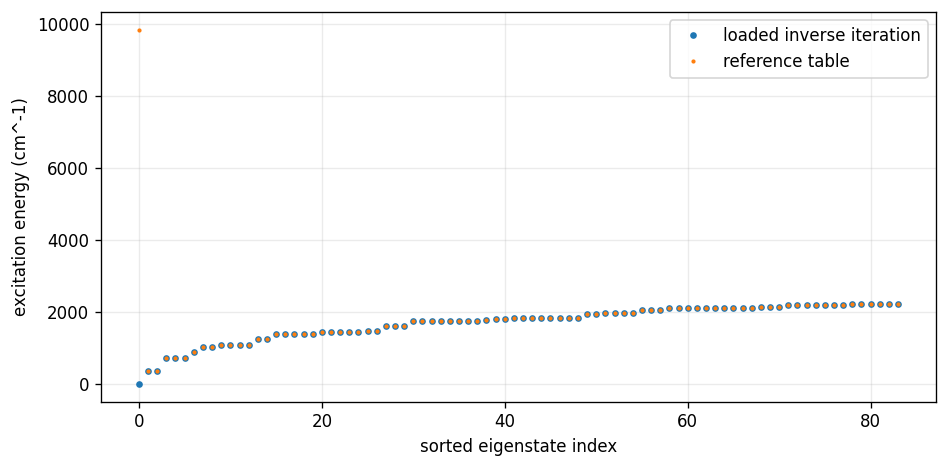

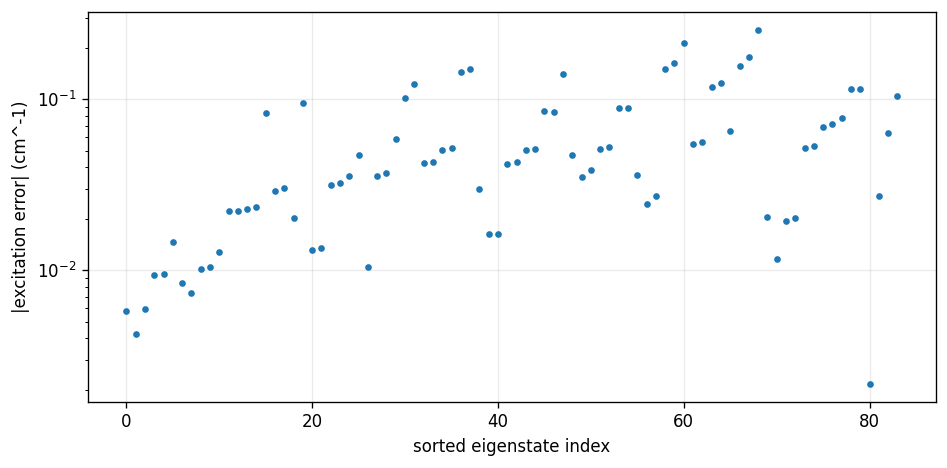

Final arrays in memory:
  lobpcg_energy_history: (84, 5)
  inverse_energy_history: (84, 6)
  eigenvalues: sorted inverse energies, shape (84,)
  eigenstates: sorted inverse states, shape (84,)
  eigensystem: sorted [value, state], shape (84, 2)
  reference_comparison: (84, 7)


In [28]:
print("summary_array columns:")
print(["idx", "abs_cm", "excitation_cm", "ref_abs_cm", "ref_table_cm", "abs_err_cm", "excitation_err_cm"])
print(summary_array[:20])
print()
print("Important: rows 1..83 should usually be compared by excitation_err_cm, not abs_err_cm.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(reference_comparison[:, 0].astype(int), reference_comparison[:, 2].astype(float), "o", ms=3, label="loaded inverse iteration")
ax.plot(reference_comparison[:, 0].astype(int), reference_comparison[:, 4].astype(float), ".", ms=3, label="reference table")
ax.set_xlabel("sorted eigenstate index")
ax.set_ylabel("excitation energy (cm^-1)")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(reference_comparison[:, 0].astype(int), np.abs(reference_comparison[:, 6].astype(float)), "o", ms=3)
ax.set_yscale("log")
ax.set_xlabel("sorted eigenstate index")
ax.set_ylabel("|excitation error| (cm^-1)")
fig.tight_layout()
plt.show()

print("Final arrays in memory:")
print("  lobpcg_energy_history:", lobpcg_energy_history.shape)
print("  inverse_energy_history:", inverse_energy_history.shape)
print("  eigenvalues: sorted inverse energies, shape", eigenvalues.shape)
print("  eigenstates: sorted inverse states, shape", None if eigenstates is None else eigenstates.shape)
print("  eigensystem: sorted [value, state], shape", None if eigensystem is None else eigensystem.shape)
print("  reference_comparison:", reference_comparison.shape)


## Optional Overlap Diagnostic

In [29]:
def compute_overlap_matrix(states: np.ndarray) -> np.ndarray:
    if states is None:
        raise RuntimeError("No states loaded. Set LOAD_TTNS_STATES=True and re-run the loading cells.")
    overlap = np.zeros((len(states), len(states)), dtype=np.complex128)
    for i in range(len(states)):
        overlap[i, i] = states[i].scalar_product(states[i])
        for j in range(i + 1, len(states)):
            overlap[i, j] = states[j].scalar_product(states[i])
            overlap[j, i] = overlap[i, j].conjugate()
    return overlap


if RUN_OVERLAP_DIAGNOSTIC:
    overlap = compute_overlap_matrix(eigenstates)
    offdiag = overlap - np.diag(np.diag(overlap))
    max_offdiag = float(np.max(np.abs(offdiag)))
    print("max |off-diagonal overlap|:", max_offdiag)
    if max_offdiag > 0.05:
        print("WARNING: final inverse-iteration states are not globally orthogonal.")

    plt.figure(figsize=(6, 5))
    plt.imshow(np.abs(overlap), origin="lower", cmap="viridis")
    plt.colorbar(label="|overlap|")
    plt.title("Loaded inverse-iteration TTNS overlap matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Overlap diagnostic skipped. Set RUN_OVERLAP_DIAGNOSTIC=True to run it.")


Overlap diagnostic skipped. Set RUN_OVERLAP_DIAGNOSTIC=True to run it.


## Dynamical Correlation Degenerate Delta-Pole Area Bar Plot

This cell evaluates `Omega_n` for each loaded inverse-iteration eigenstate, merges numerically degenerate poles, and plots the summed delta-pole area `2*sum(Omega_n)`. No broadening or peak finding is applied.


x: sum Omega_n over loaded states = 9.67606855758e-05
y: sum Omega_n over loaded states = 0.000324984572524
z: sum Omega_n over loaded states = 0.000323840179054

Degeneracy-merged discrete delta-pole areas from inverse-iteration eigenstates
Omega_n = sum_components |<phi_n|mu_component|0>|^2 / a
zero excitation cutoff cm^-1: 1.0
degeneracy tolerance cm^-1: 0.1
minimum plotted 2*sum(Omega_n): 1e-06
raw nonzero poles before merging: 83
degenerate groups before area cutoff: 48
number of merged peaks plotted: 8
rank_range  initial_indices  peak_E    peak_cm  2*Omega_sum  Omega_sum    n_members  cm_span     Omega_x_sum  Omega_y_sum  Omega_z_sum
----------  ---------------  --------  -------  -----------  -----------  ---------  ----------  -----------  -----------  -----------
1-2         2,1              0.360995  360.995  0.000200954  0.000100477  2          0.00168641  1.52677e-09  4.96893e-05  5.07863e-05
6           6                0.900667  900.667  7.7066e-05   3.8533e-05   1      

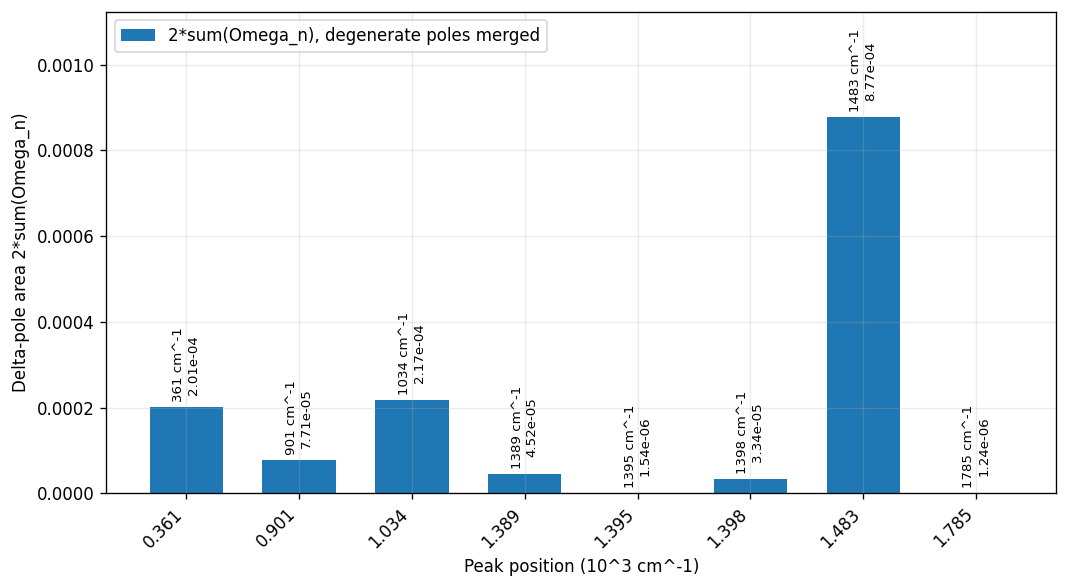


All plotted bar x positions and eigenvalue information:
x  rank_range  initial_indices  peak_E    peak_cm  2*Omega_sum
-  ----------  ---------------  --------  -------  -----------
0  1-2         2,1              0.360995  360.995  0.000200954
1  6           6                0.900667  900.667  7.7066e-05 
2  7-8         8,7              1.03413   1034.13  0.000217461
3  15          15               1.38905   1389.05  4.52222e-05
4  16-17       16,17            1.39471   1394.71  1.53871e-06
5  19          19               1.39778   1397.78  3.34193e-05
6  25-26       25,26            1.4832    1483.2   0.000877042
7  38          38               1.78515   1785.15  1.24177e-06

All sorted inverse eigenvalues minus ground-state energy:
ground_energy: 9.837412699236129
x  rank  initial_index  eigenvalue_minus_ground
-  ----  -------------  -----------------------
 0     0              0  0
 1     1              2  0.3609942221322875
 2     2              1  0.3609959085454282
 3     3  

In [30]:
from Dipole_moment import get_mu_ttno_linear
from pytreenet.contractions.state_operator_contraction import get_matrix_element
from utils_CH3CN import get_ch3cn_ir_dipole_derivative


DIPOLE_COMPONENTS = ("x", "y", "z")
DELTA_SCALE_A = 1.0
ZERO_EXCITATION_CUTOFF_CM = 1.0
DEGENERACY_TOLERANCE_CM = 0.1
MIN_TWO_OMEGA = 1e-6
USE_LOG_Y = False
ANNOTATE_BARS = True


def format_table(rows, columns):
    formatted_rows = []
    for source_row in rows:
        formatted = {}
        for col in columns:
            value = source_row.get(col, "")
            if isinstance(value, float):
                value = f"{value:.6g}"
            formatted[col] = str(value)
        formatted_rows.append(formatted)
    widths = {col: max([len(col)] + [len(row[col]) for row in formatted_rows]) for col in columns}
    fmt = "  ".join("{:<" + str(widths[col]) + "}" for col in columns)
    print(fmt.format(*columns))
    print(fmt.format(*["-" * widths[col] for col in columns]))
    for formatted in formatted_rows:
        print(fmt.format(*[formatted[col] for col in columns]))


def collapse_degenerate_rows(rows, tolerance_cm):
    groups = []
    current = []
    for row in sorted(rows, key=lambda item: item["peak_cm"]):
        if not current:
            current = [row]
            continue
        if row["peak_cm"] - current[0]["peak_cm"] <= tolerance_cm:
            current.append(row)
        else:
            groups.append(current)
            current = [row]
    if current:
        groups.append(current)

    collapsed = []
    for group in groups:
        omega_sum = float(sum(row["Omega_n"] for row in group))
        two_omega_sum = 2.0 * omega_sum
        component_sums = {
            component: float(sum(row[f"Omega_{component}"] for row in group))
            for component in DIPOLE_COMPONENTS
        }
        if omega_sum > 0.0:
            peak_E = float(sum(row["peak_E"] * row["Omega_n"] for row in group) / omega_sum)
            peak_cm = float(sum(row["peak_cm"] * row["Omega_n"] for row in group) / omega_sum)
        else:
            peak_E = float(np.mean([row["peak_E"] for row in group]))
            peak_cm = float(np.mean([row["peak_cm"] for row in group]))
        ranks = [row["rank"] for row in group]
        initial_indices = [row["initial_index"] for row in group]
        collapsed.append({
            "rank_range": f"{min(ranks)}-{max(ranks)}" if len(ranks) > 1 else str(ranks[0]),
            "initial_indices": ",".join(str(index) for index in initial_indices),
            "peak_E": peak_E,
            "peak_cm": peak_cm,
            "Omega_sum": omega_sum,
            "2*Omega_sum": two_omega_sum,
            "Omega_x_sum": component_sums["x"],
            "Omega_y_sum": component_sums["y"],
            "Omega_z_sum": component_sums["z"],
            "n_members": len(group),
            "cm_span": float(group[-1]["peak_cm"] - group[0]["peak_cm"]),
        })
    return collapsed


if eigenstates is None:
    raise RuntimeError("No inverse-iteration states are loaded. Run the loading cells first.")

for state in eigenstates:
    state.normalise()
ground_state = eigenstates[0]

initial_indices = np.asarray(final_sort_order, dtype=int) if "final_sort_order" in globals() else np.arange(len(eigenvalues))

dipole_derivative_by_component = {
    component: get_ch3cn_ir_dipole_derivative(normalize=False, component=component)
    for component in DIPOLE_COMPONENTS
}
mu_ttno_by_component = {
    component: get_mu_ttno_linear(N, ground_state, dipole_derivative_by_component[component])
    for component in DIPOLE_COMPONENTS
}

omega_by_component = {}
for component in DIPOLE_COMPONENTS:
    mu_ttno = mu_ttno_by_component[component]
    amplitudes = np.array(
        [get_matrix_element(state.conjugate(), mu_ttno, ground_state) for state in eigenstates],
        dtype=np.complex128,
    )
    # For A = B = dipole moment, Omega_n = <0|mu|n><n|mu|0>/a = |<n|mu|0>|^2/a.
    omega_by_component[component] = (np.abs(amplitudes) ** 2 / DELTA_SCALE_A).real
    print(f"{component}: sum Omega_n over loaded states = {np.sum(omega_by_component[component]):.12g}")

omega_total = np.sum([omega_by_component[c] for c in DIPOLE_COMPONENTS], axis=0)
two_omega = 2.0 * omega_total
excitation_energies = np.asarray(eigenvalues, dtype=np.float64) - float(eigenvalues[0])
excitation_cm = 1000.0 * excitation_energies

raw_rows = []
for rank, initial_index, peak_E, peak_cm, omega_n, doubled in zip(
    range(len(eigenvalues)),
    initial_indices,
    excitation_energies,
    excitation_cm,
    omega_total,
    two_omega,
):
    if peak_cm <= ZERO_EXCITATION_CUTOFF_CM:
        continue
    raw_rows.append({
        "rank": int(rank),
        "initial_index": int(initial_index),
        "peak_E": float(peak_E),
        "peak_cm": float(peak_cm),
        "Omega_n": float(omega_n),
        "2*Omega_n": float(doubled),
        "Omega_x": float(omega_by_component["x"][rank]),
        "Omega_y": float(omega_by_component["y"][rank]),
        "Omega_z": float(omega_by_component["z"][rank]),
    })

merged_rows_all = collapse_degenerate_rows(raw_rows, DEGENERACY_TOLERANCE_CM)
area_rows = [row for row in merged_rows_all if row["2*Omega_sum"] >= MIN_TWO_OMEGA]
area_rows = sorted(area_rows, key=lambda row: row["peak_cm"])

print()
print("Degeneracy-merged discrete delta-pole areas from inverse-iteration eigenstates")
print("Omega_n = sum_components |<phi_n|mu_component|0>|^2 / a")
print("zero excitation cutoff cm^-1:", ZERO_EXCITATION_CUTOFF_CM)
print("degeneracy tolerance cm^-1:", DEGENERACY_TOLERANCE_CM)
print("minimum plotted 2*sum(Omega_n):", MIN_TWO_OMEGA)
print("raw nonzero poles before merging:", len(raw_rows))
print("degenerate groups before area cutoff:", len(merged_rows_all))
print("number of merged peaks plotted:", len(area_rows))
format_table(area_rows, [
    "rank_range",
    "initial_indices",
    "peak_E",
    "peak_cm",
    "2*Omega_sum",
    "Omega_sum",
    "n_members",
    "cm_span",
    "Omega_x_sum",
    "Omega_y_sum",
    "Omega_z_sum",
])

if not area_rows:
    raise RuntimeError("No peaks remain after the current 2*sum(Omega_n) cutoff.")

fig_area_bar, ax_area_bar = plt.subplots(figsize=(max(9, 0.7 * len(area_rows)), 5.0))
x = np.arange(len(area_rows))
bar_values = [row["2*Omega_sum"] for row in area_rows]
bars = ax_area_bar.bar(x, bar_values, width=0.65, label="2*sum(Omega_n), degenerate poles merged")
ax_area_bar.set_xticks(x)
ax_area_bar.set_xticklabels([f"{row['peak_E']:.3f}" for row in area_rows], rotation=45, ha="right")
ax_area_bar.set_xlabel("Peak position (10^3 cm^-1)")
ax_area_bar.set_ylabel("Delta-pole area 2*sum(Omega_n)")
if USE_LOG_Y:
    ax_area_bar.set_yscale("log")
    ax_area_bar.set_ylabel("Delta-pole area 2*sum(Omega_n) (log scale)")
else:
    ax_area_bar.set_ylim(0.0, max(bar_values) * 1.28)
if ANNOTATE_BARS:
    labels = [f"{row['peak_cm']:.0f} cm^-1\n{row['2*Omega_sum']:.2e}" for row in area_rows]
    ax_area_bar.bar_label(bars, labels=labels, padding=3, fontsize=8, rotation=90)
ax_area_bar.legend()
fig_area_bar.tight_layout()
plt.show()

print()
print("All plotted bar x positions and eigenvalue information:")
format_table([
    {
        "x": int(x_position),
        "rank_range": row["rank_range"],
        "initial_indices": row["initial_indices"],
        "peak_E": row["peak_E"],
        "peak_cm": row["peak_cm"],
        "2*Omega_sum": row["2*Omega_sum"],
    }
    for x_position, row in zip(x, area_rows)
], ["x", "rank_range", "initial_indices", "peak_E", "peak_cm", "2*Omega_sum"])

print()
ground_energy = float(eigenvalues[0])
print("All sorted inverse eigenvalues minus ground-state energy:")
print("ground_energy:", f"{ground_energy:.16g}")
print("x  rank  initial_index  eigenvalue_minus_ground")
print("-  ----  -------------  -----------------------")
for x_value, (initial_index, eigenvalue) in enumerate(zip(initial_indices, eigenvalues)):
    shifted_eigenvalue = float(eigenvalue) - ground_energy
    print(f"{x_value:>2d}  {x_value:>4d}  {int(initial_index):>13d}  {shifted_eigenvalue:.16g}")



Integrated IR intensities from LOBPCG delta poles
frequency unit used in formula: cm^-1 = 1000 * peak_E
transition dipole conversion: 1 a.u. = 2.541746473 Debye
area convention: 2*Omega_sum is used as the transition dipole squared, matching ORCA T2 in the harmonic limit
excluded peak_E values (10^3 cm^-1): (1.785,)
exclusion tolerance (10^3 cm^-1): 0.01
Excluded small peaks:
rank_range  initial_indices  peak_E   peak_cm  2*Omega_sum
----------  ---------------  -------  -------  -----------
38          38               1.78515  1785.15  1.24177e-06
rank_range  initial_indices  peak_E    peak_cm  mu2_Debye2   A_IR_km_mol  A_x_km_mol   A_y_km_mol   A_z_km_mol 
----------  ---------------  --------  -------  -----------  -----------  -----------  -----------  -----------
1-2         2,1              0.360995  360.995  0.00129826   1.17478      1.78509e-05  0.580966     0.593792   
6           6                0.900667  900.667  0.000497883  1.12404      1.12404      1.22244e-08  1.27085e-

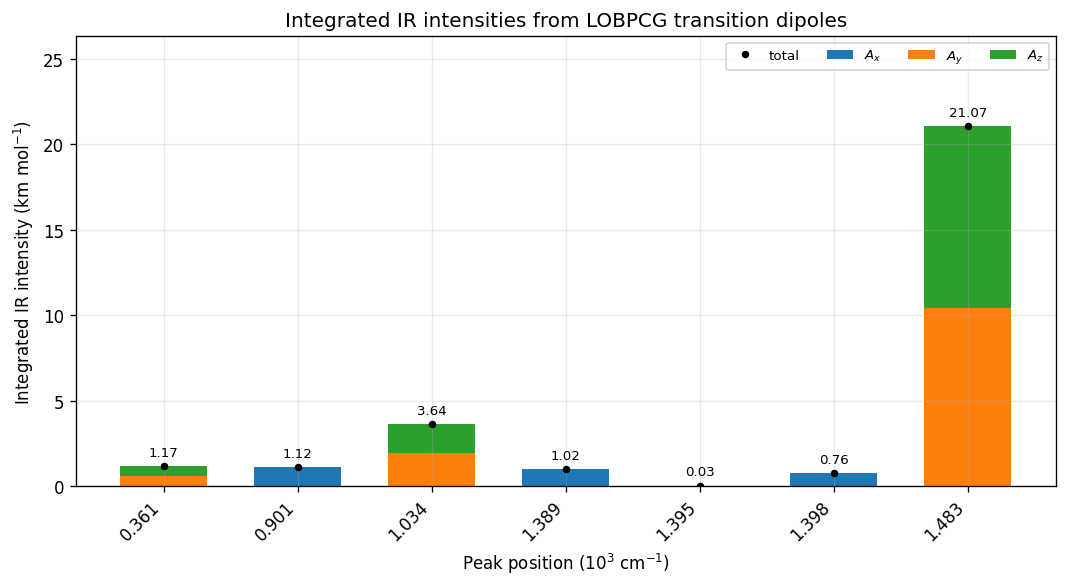

In [33]:
# --- IR_INTENSITY_PLOT_START ---
# Practical integrated IR intensity:
# A_IR[km/mol] = 2.50664 * nu_tilde[cm^-1] * sum_alpha |<Psi_f|Delta mu_alpha|Psi_0>|^2[Debye^2].
# The previous area plot used peak_E in 10^3 cm^-1 and 2*Omega_sum.
# Harmonic calibration shows 2*Omega_sum matches ORCA T2, so use 2*Omega_sum as the transition dipole squared.
# peak_cm = 1000*peak_E accounts for the earlier 10^3 cm^-1 energy scale.
IR_INTENSITY_FACTOR = 2.50664
AU_DIPOLE_TO_DEBYE = 2.541746473
PLOT_IR_INTENSITY_LOG_Y = False
ANNOTATE_IR_INTENSITY_BARS = True
# Keep the merged 1.389+1.398 peak; only remove the small peak near 1.785.
IR_INTENSITY_EXCLUDED_PEAK_E = (1.785,)  # in 10^3 cm^-1
IR_INTENSITY_EXCLUSION_TOLERANCE = 0.01  # in 10^3 cm^-1

if "area_rows" not in globals() or not area_rows:
    raise RuntimeError("Run the delta-pole area cell first so area_rows is available.")

ir_intensity_rows = []
excluded_ir_intensity_rows = []
for row in area_rows:
    peak_cm = float(row.get("peak_cm", 1000.0 * float(row["peak_E"])))
    peak_E_10e3_cm = float(row.get("peak_E", peak_cm / 1000.0))
    if any(
        abs(peak_E_10e3_cm - excluded_peak_E) <= IR_INTENSITY_EXCLUSION_TOLERANCE
        for excluded_peak_E in IR_INTENSITY_EXCLUDED_PEAK_E
    ):
        excluded_ir_intensity_rows.append({
            "rank_range": row["rank_range"],
            "initial_indices": row["initial_indices"],
            "peak_E": peak_E_10e3_cm,
            "peak_cm": peak_cm,
            "2*Omega_sum": float(row["2*Omega_sum"]),
        })
        continue

    mu2_au = float(row["2*Omega_sum"]) * float(DELTA_SCALE_A)
    mu2_debye2 = mu2_au * AU_DIPOLE_TO_DEBYE**2
    intensity_total = IR_INTENSITY_FACTOR * peak_cm * mu2_debye2

    component_intensities = {}
    component_mu2_debye2 = {}
    for component in DIPOLE_COMPONENTS:
        comp_mu2_au = 2.0 * float(row[f"Omega_{component}_sum"]) * float(DELTA_SCALE_A)
        comp_mu2_debye2 = comp_mu2_au * AU_DIPOLE_TO_DEBYE**2
        component_mu2_debye2[component] = comp_mu2_debye2
        component_intensities[component] = IR_INTENSITY_FACTOR * peak_cm * comp_mu2_debye2

    ir_intensity_rows.append({
        "rank_range": row["rank_range"],
        "initial_indices": row["initial_indices"],
        "peak_E": peak_E_10e3_cm,
        "peak_cm": peak_cm,
        "mu2_Debye2": mu2_debye2,
        "A_IR_km_mol": intensity_total,
        "A_x_km_mol": component_intensities["x"],
        "A_y_km_mol": component_intensities["y"],
        "A_z_km_mol": component_intensities["z"],
        "mu2_x_Debye2": component_mu2_debye2["x"],
        "mu2_y_Debye2": component_mu2_debye2["y"],
        "mu2_z_Debye2": component_mu2_debye2["z"],
    })

if not ir_intensity_rows:
    raise RuntimeError("No peaks remain after filtering the selected small IR-intensity peaks.")

print("Integrated IR intensities from LOBPCG delta poles")
print("frequency unit used in formula: cm^-1 = 1000 * peak_E")
print("transition dipole conversion: 1 a.u. =", AU_DIPOLE_TO_DEBYE, "Debye")
print("area convention: 2*Omega_sum is used as the transition dipole squared, matching ORCA T2 in the harmonic limit")
print("excluded peak_E values (10^3 cm^-1):", IR_INTENSITY_EXCLUDED_PEAK_E)
print("exclusion tolerance (10^3 cm^-1):", IR_INTENSITY_EXCLUSION_TOLERANCE)
if excluded_ir_intensity_rows:
    print("Excluded small peaks:")
    format_table(excluded_ir_intensity_rows, [
        "rank_range",
        "initial_indices",
        "peak_E",
        "peak_cm",
        "2*Omega_sum",
    ])
format_table(ir_intensity_rows, [
    "rank_range",
    "initial_indices",
    "peak_E",
    "peak_cm",
    "mu2_Debye2",
    "A_IR_km_mol",
    "A_x_km_mol",
    "A_y_km_mol",
    "A_z_km_mol",
])

x_ir = np.arange(len(ir_intensity_rows))
A_x = np.array([row["A_x_km_mol"] for row in ir_intensity_rows], dtype=np.float64)
A_y = np.array([row["A_y_km_mol"] for row in ir_intensity_rows], dtype=np.float64)
A_z = np.array([row["A_z_km_mol"] for row in ir_intensity_rows], dtype=np.float64)
A_total = np.array([row["A_IR_km_mol"] for row in ir_intensity_rows], dtype=np.float64)

fig_ir, ax_ir = plt.subplots(figsize=(max(9, 0.75 * len(ir_intensity_rows)), 5.0))
bottom = np.zeros_like(A_total)
for component, values in (("x", A_x), ("y", A_y), ("z", A_z)):
    ax_ir.bar(x_ir, values, bottom=bottom, width=0.65, label=fr"$A_{{{component}}}$")
    bottom += values
ax_ir.plot(x_ir, A_total, "ko", ms=3.5, label="total")

ax_ir.set_xticks(x_ir)
ax_ir.set_xticklabels([f"{row['peak_E']:.3f}" for row in ir_intensity_rows], rotation=45, ha="right")
ax_ir.set_xlabel(r"Peak position $(10^3\ \mathrm{cm}^{-1})$")
ax_ir.set_ylabel(r"Integrated IR intensity $(\mathrm{km\ mol}^{-1})$")
ax_ir.set_title("Integrated IR intensities from LOBPCG transition dipoles")
if PLOT_IR_INTENSITY_LOG_Y:
    ax_ir.set_yscale("log")
elif len(A_total) and np.max(A_total) > 0.0:
    ax_ir.set_ylim(0.0, np.max(A_total) * 1.25)
if ANNOTATE_IR_INTENSITY_BARS:
    label_offset = 0.02 * float(np.max(A_total)) if len(A_total) else 0.0
    positive_totals = A_total[A_total > 0.0]
    for xpos, total in zip(x_ir, A_total):
        if PLOT_IR_INTENSITY_LOG_Y and len(positive_totals):
            text_y = total * 1.08 if total > 0.0 else float(np.min(positive_totals))
        else:
            text_y = total + label_offset
        ax_ir.text(
            xpos,
            text_y,
            f"{total:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=0,
            clip_on=False,
        )
ax_ir.legend(fontsize=8, ncol=4)
fig_ir.tight_layout()
plt.show()
# --- IR_INTENSITY_PLOT_END ---
